<a href="https://colab.research.google.com/github/A-D-Vargas/PI_Mineria_Datos_1/blob/main/2_notebooks/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se desarrolló en 03_eda.ipynb.
Se incluye análisis univariado, bivariado y multivariado. Cada visualización incluye una interpretación vinculada con una pregunta u objetivo definido por el grupo.

#Carga de Datos y Vista Previa

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/A-D-Vargas/PI_Mineria_Datos_1/refs/heads/main/1_data/processed/streaming_users_limpio.csv"
df = pd.read_csv(url)

df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,1.0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2.0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0.0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1.0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8018 entries, 0 to 8017
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8018 non-null   int64  
 1   age                       8018 non-null   int64  
 2   subscription_plan         8018 non-null   object 
 3   monthly_watch_time_mins   8018 non-null   float64
 4   country                   8018 non-null   object 
 5   favorite_genre            8018 non-null   object 
 6   last_login_date           8018 non-null   object 
 7   customer_support_tickets  8018 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 501.3+ KB


,user_id,age,monthly_watch_time_mins,customer_support_tickets
count,8018.000000,8018.000000,8018.000000,8018.000000
mean,13998.306685,33.615116,793.788401,0.803692
std,2309.066823,11.560268,487.492414,0.893828
min,10000.000000,4.000000,0.000000,0.000000
25%,11998.250000,25.000000,499.375000,0.000000
50%,13997.500000,33.000000,758.700000,1.000000
75%,15996.750000,41.000000,1029.225000,1.000000
max,17999.000000,80.000000,4193.700000,5.000000


#Análisis Univariado:

--- GRÁFICOS EXPLORATORIOS (EDA) ---



/tmp/ipykernel_7975/1844577500.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='favorite_genre', order=orden_generos, palette='viridis')


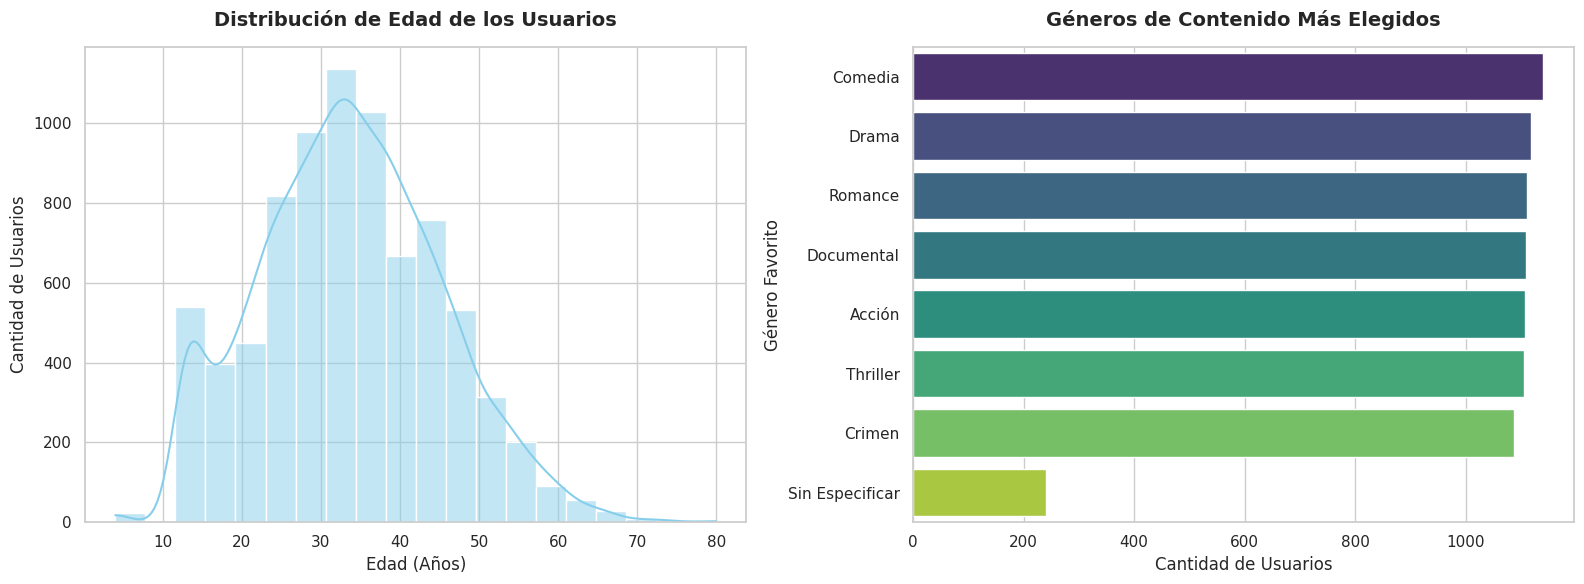

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

print("--- GRÁFICOS EXPLORATORIOS (EDA) ---\n")

# Gráfico 1: Histograma de Edades
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue')
plt.title('Distribución de Edad de los Usuarios', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Gráfico 2: Conteo de Género Favorito
plt.subplot(1, 2, 2)
orden_generos = df['favorite_genre'].value_counts().index
sns.countplot(data=df, y='favorite_genre', order=orden_generos, palette='viridis')
plt.title('Géneros de Contenido Más Elegidos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Usuarios', fontsize=12)
plt.ylabel('Género Favorito', fontsize=12)

plt.tight_layout()
plt.show()

Gráfico 1: Histograma de Edad

Pregunta/Objetivo: ¿Cuál es el rango de edad de usuarios y en qué edad se concentra la mayor cantidad de clientes?

Interpretación: la mayoría de los usuarios se concentran en un público joven-adulto, aunque la plataforma es consumida por un rango amplio (desde niños pequeños en cuentas familiares hasta adultos mayores).

Gráfico 2: Gráfico de Barras de Género Favorito

Pregunta/Objetivo: ¿Cuáles son los géneros audiovisuales que más popularidad generan en la plataforma en general?

Interpretación: permite identificar rápidamente cuál es el contenido "estrella" (más visto) para orientar futuras compras de licencias o producciones originales.

#Analisis Bivariado

/tmp/ipykernel_7975/842007626.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', palette='Pastel1', ax=axes[0])
/tmp/ipykernel_7975/842007626.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='favorite_genre', y='age', palette='muted', errorbar=None, ax=axes[1])


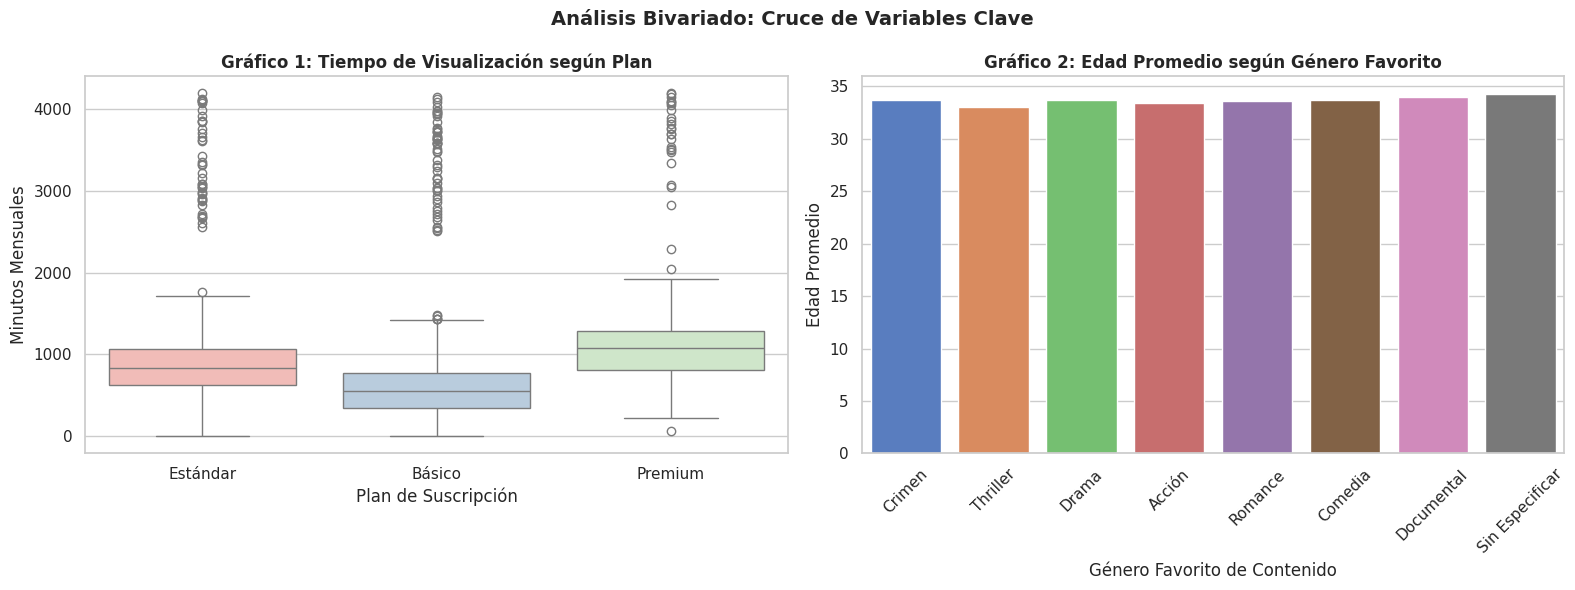

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Bivariado: Cruce de Variables Clave', fontsize=14, fontweight='bold')

# Gráfico 1: Tipo de Plan vs. Tiempo de Visualización (Categórica vs. Continua)
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', palette='Pastel1', ax=axes[0])
axes[0].set_title('Gráfico 1: Tiempo de Visualización según Plan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Plan de Suscripción')
axes[0].set_ylabel('Minutos Mensuales')

# Gráfico 2: Género Favorito vs. Edad del Usuario (Categórica vs. Continua)
sns.barplot(data=df, x='favorite_genre', y='age', palette='muted', errorbar=None, ax=axes[1])
axes[1].set_title('Gráfico 2: Edad Promedio según Género Favorito', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género Favorito de Contenido')
axes[1].set_ylabel('Edad Promedio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Gráfico 1: Tiempo de Visualización según Plan**

**Pregunta / Objetivo**:
¿Existe una diferencia significativa en la cantidad de tiempo de reproducción mensual entre los usuarios según el nivel de suscripción que pagan (Básico, Estándar o Premium)?

**Iterpretación:** el gráfico de cajas muestra que el tiempo de uso sube notablemente según el plan que paga cada usuario.

* Los del plan Básico son los que menos tiempo pasan en la plataforma (la mitad ve menos de 557 minutos al mes).

* Los del plan Premium son los que más contenido miran (la mitad supera los 1,081 minutos mensuales) y, además, la gran mayoría (el 75%) consume más de 805 minutos.

Esto nos demuestra que las personas que pagan un plan más caro pasan mucho más tiempo enganchadas a la pantalla. Esto confirma que los beneficios y el contenido del plan Premium funcionan muy bien para mantener a los clientes activos y conformes con el servicio.


**Gráfico 2: Edad Promedio según Género Favorito**

**Pregunta / Objetivo:**
¿La edad de los usuarios influye en el tipo de películas o series que eligen ver? ¿Hay géneros preferidos por los más jóvenes o por los más grandes?

**Interpretación:**
el gráfico de barras muestra que la edad promedio es casi la misma para todos los géneros de contenido, donde la edad promedio de los usuarios ronda siempre entre los 33 y 34 años.

En conclusión los gustos no están divididos por la edad. Los usuarios jóvenes y los más grandes consumen los mismos tipos de categorías, lo que significa que la plataforma no necesita separar sus contenidos pensando en "público joven" o "público adulto" según el género.



#Analisis multivariado

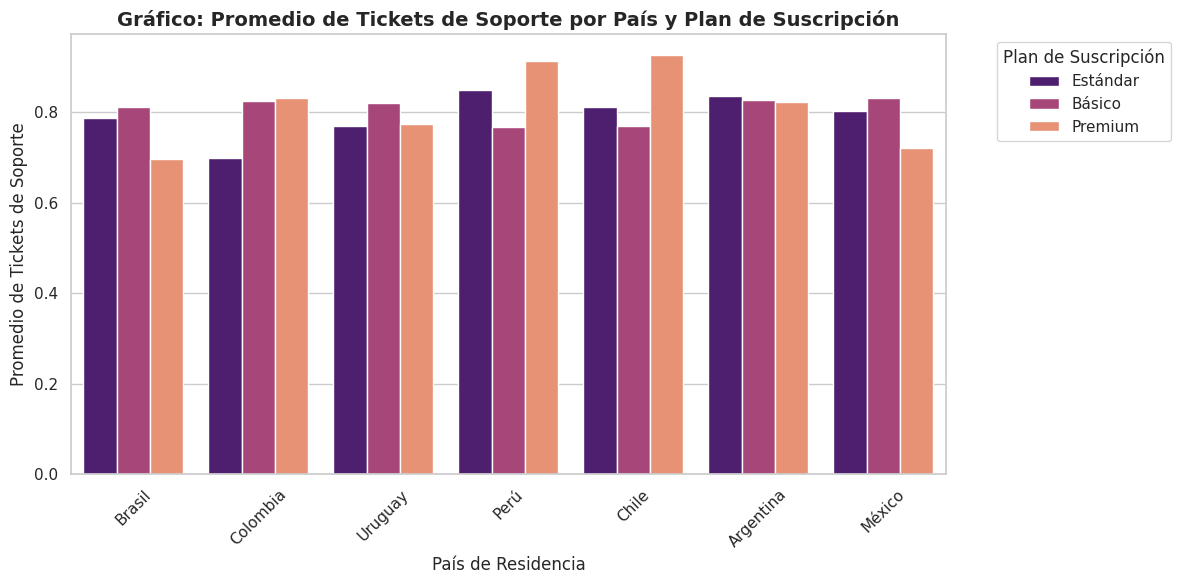

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Creamos un gráfico de barras cruzando País (X), Tickets (Y) y Plan (Color)
sns.barplot(
    data=df,
    x='country',
    y='customer_support_tickets',
    hue='subscription_plan',
    palette='magma',
    errorbar=None
)

plt.title('Gráfico: Promedio de Tickets de Soporte por País y Plan de Suscripción', fontsize=14, fontweight='bold')
plt.xlabel('País de Residencia')
plt.ylabel('Promedio de Tickets de Soporte')
plt.xticks(rotation=45)
plt.legend(title='Plan de Suscripción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Pregunta / Objetivo:**
¿El nivel de satisfacción o los problemas técnicos de los usuarios varían según el país donde viven y el plan que pagan? Queremos identificar en qué países y planes se están generando la mayor cantidad de reclamos para mejorar la atención al cliente.

**Interpretación:**
al analizar los reclamos de soporte técnico combinando los países y los planes, descubrimos:

Aunque uno esperaría que los usuarios Premium reclamen menos por tener el mejor plan, Chile y Perú (con plan Premium) son los que más reclamos hacen. En cambio, en Brasil y México, el plan Premium es el que menos problemas reporta, siendo los usuarios del plan Básico con más reclamos.

Este análisis nos sirve para detectar que la plataforma tiene problemas de estabilidad o de atención específicos para los clientes de más valor en Chile y Perú, lo que nos permite sugerirle a la empresa que revise qué está fallando con el servicio Premium en esos países de manera urgente.